Perform NicheNet analysis starting from an AnnData object: step-by-step analysis
================

In this notebook, you can learn how to perform a basic NicheNet analysis on an AnnData object containing single-cell expression data. The steps of this vignette can also be adapted for other single-cell or bulk frameworks.

Assuming you have captured the changes in gene expression resulting from your cell-cell communication (CCC) process of interest, a NicheNet analysis can help you to generate hypotheses about the CCC process. Specifically, NicheNet can predict 1) which ligands from the microenvironment or cell population(s) ("sender/niche") are most likely to affect target gene expression in an interacting cell population ("receiver/target") and 2) which specific target genes are affected by which of these predicted ligands.

To perform a NicheNet analysis, three features are extracted from the input data: the potential ligands, the gene set of interest, and the background gene set. This vignette will extract each feature as described in this flowchart:

<img src="./images/flowchart.svg" style="width:70.0%" />

As example expression data of interacting cells, we will use mouse NICHE-seq data to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection (Medaglia et al. 2017). We will focus on CD8 T cells as the receiver population, and as this dataset contains two conditions (before and after LCMV infection), the differentially expressed genes between these two conditions in CD8 T cells will be used as our gene set of interest. We will then prioritize which ligands from the microenvironment (sender-agnostic approach) and from specific immune cell populations like monocytes, dendritic cells, NK cells, B cells, and CD4 T cells (sender-focused approach) can regulate and induce these observed gene expression changes.

## Prepare NicheNet analysis

### Load packages

In [1]:
from nichenetpy.prediction import LigandActivityPredictor
from nichenetpy.network import LigandReceptorNetwork, WeightedNetwork
from nichenetpy.gene_symbol import mouse_alias_info
from nichenetpy.wrappers import (
    run_nichenet,
    create_ligand_activity_hist,
    create_ligand_activity_heatmap,
    create_regulatory_potential_heatmap,
    create_prior_interaction_potential_heatmap,
    create_prior_interaction_potential_heatmap,
    create_lfc_heatmap
)
from nichenetpy.io import read_ligand_target_matrix

import anndata
import scanpy as sc
import os
import requests

Download the model files

In [2]:
model_path = os.path.normpath("./tutorial_files/model/mouse")
if not os.path.exists(model_path):
    os.makedirs(model_path)
for filename in (
    "gr_mouse.bin",
    "ligand_target_matrix_mouse.bin",
    "lr_network_mouse.bin",
    "lr_sig_mouse.bin"
):
    file_path = os.path.join(model_path, filename)
    if not os.path.exists(file_path):
        res = requests.get(f"https://zenodo.org/records/14858034/files/{filename}")
        with open(file_path, "wb") as file:
            file.write(res.content)

Download the AnnData object

In [3]:
data_path = os.path.normpath("./tutorial_files/AnnData")
if not os.path.exists(data_path):
    os.makedirs(data_path)
filename = "annData3531889.h5"
file_path = os.path.join(data_path, filename)
if not os.path.exists(file_path):
    res = requests.get(f"https://zenodo.org/records/14859451/files/{filename}")
    with open(file_path, "wb") as file:
        file.write(res.content)

### Read in the expression data of interacting cells

In [4]:
ann = anndata.io.read_h5ad(os.path.join(data_path, "annData3531889.h5"))
ann.var_names = ann.var["gene"]
ann

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'aggregate', 'res.0.6', 'celltype'
    var: 'gene'
    layers: 'counts', 'data', 'scale.data'

Additionally, if your expression data has the older gene symbols, you may want to use our alias conversion function to avoid the loss of gene names.

In [5]:
mouse_alias_info.alias_to_symbol(ann)

Visualize which cell populations are present: CD4 T cells (including regulatory T cells), CD8 T cells, B cells, NK cells, dendritic cells (DCs) and inflammatory monocytes.

In [6]:
celltype_counts = ann.obs["celltype"].value_counts()
celltype_counts

celltype
CD4 T    2562
CD8 T    1645
B         382
Treg      199
NK        131
Mono       90
DC         18
Name: count, dtype: int64

c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 13541 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
c:\Users\victorm\Documents\nichenetpy\.hatch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


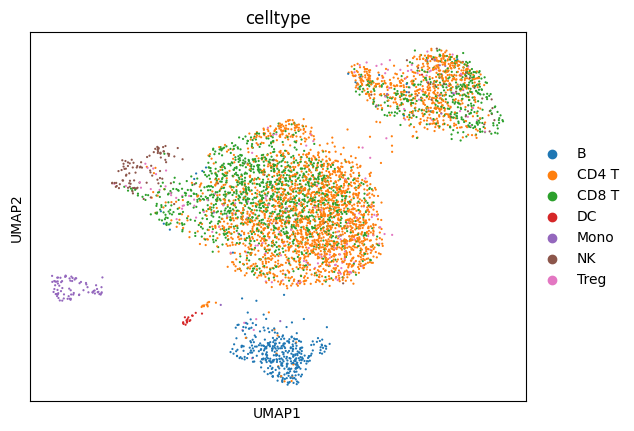

In [7]:
# need to make a copy because sc.tl.umap
# alters the AnnData object and causes an error in DotPlot
# later on, I assume this is a bug in scanpy
temp = ann.copy()
temp.X = temp.layers["data"]
sc.pp.neighbors(temp)
sc.tl.umap(temp)
sc.pl.umap(temp, gene_symbols="gene", color="celltype", size=10)

Visualize the data to see to which condition cells belong. The metadata column that denotes the condition (steady-state or after LCMV infection) is here called "aggregate".

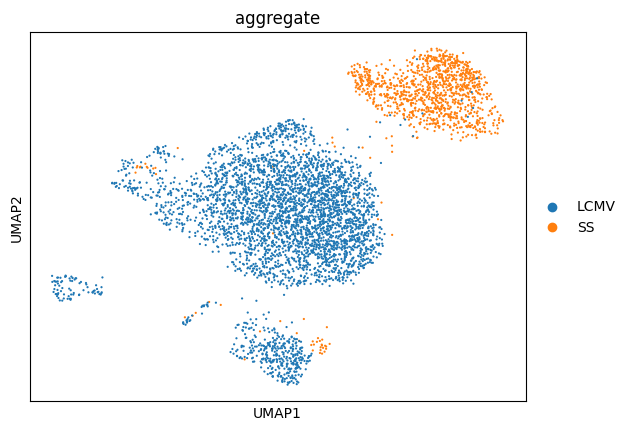

In [8]:
sc.pl.umap(temp, gene_symbols="gene", color="aggregate", size=10)

## Read in NicheNet's networks

The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene, and it is used to run the ligand activity analysis. The ligand-receptor network contains information on potential ligand-receptor bindings, and it is used to identify potential ligands. 

In [9]:
predictor = LigandActivityPredictor(*read_ligand_target_matrix(os.path.join(model_path, "ligand_target_matrix_mouse.bin")))
lr_network = LigandReceptorNetwork(filename=os.path.join(model_path, "lr_network_mouse.bin"))
lr_sig = WeightedNetwork(filename=os.path.join(model_path, "lr_sig_mouse.bin"))

## Perform the NicheNet analysis

In this case study, we want to apply NicheNet to predict which ligands expressed by the microenvironment (sender-agnostic) and immune cells in the T cell area of the lymph node (sender-focused) are most likely to have induced the differential expression in CD8 T cells after LCMV infection. We recommend users to run both the "sender-agnostic" and "sender-focused" approach. These approaches only affect the list of potential ligands that are considered for prioritization. As described in the flowchart above, we do not define any sender populations in the ‘sender agnostic’ approach but consider all ligands for which its cognate receptor is expressed in the receiver population. The sender-focused approach will then filter the list of ligands to ones where the ligands are expressed in the sender cell population(s). 

The receiver cell population is the ‘CD8 T’ cell population, and the gene set of interest are the genes differentially expressed in CD8 T cells after LCMV infection. Thus, the condition of interest is ‘LCMV’, whereas the reference/steady-state condition is ‘SS’. The column containing condition information is ‘aggregate’. The method to calculate differential expression is the Wilcoxon test. The number of top-ranked ligands that are further used to predict active target genes and construct an active ligand-receptor network is 30. The number of target genes to consider per ligand when performing the target gene inference is 100. We only retain ligands and receptors that are expressed in at least a predefined fraction of cells in one cluster (default: 5%).

In [10]:
sender_celltypes = ("CD4 T", "Treg", "Mono", "NK", "B", "DC")
res = run_nichenet(
    ann,
    predictor,
    lr_network,
    "CD8 T",
    "aggregate",
    "LCMV",
    "SS",
    sender_celltypes=sender_celltypes,
    lr_sig=lr_sig,
    get_ltl=True,
    get_lfc=True
)
best_upstream_ligands = res["best_upstream_ligands"]
ligand_activities_sorted = res["ligand_activities_sorted"]
active_ligand_target_links = res["active_ligand_target_links"]
ligand_receptor_links = res["ligand_receptor_links"]
ligand_activities_sorted_focused = res["ligand_activities_sorted_focused"]
active_ligand_target_links_focused = res["active_ligand_target_links_focused"]
ligand_receptor_links_focused = res["ligand_receptor_links_focused"]
ann_focused = res["ann_focused"]
lfcs = res["lfcs"]
best_upstream_ligands_focused = res["best_upstream_ligands_focused"]

The performance metrics indicate that the 30 top-ranked ligands can predict the viral response reasonably, implying that the ranking of the ligands might be accurate. However, it is possible that for some gene sets, the target gene prediction performance of the top-ranked ligands would not be much better than random prediction. In that case, prioritization of ligands will be less trustworthy.

We will use the top 30 ligands to predict active target genes and construct an active ligand-receptor network. However, the choice of looking only at the 30 top-ranked ligands for further biological interpretation is based on biological intuition and is quite arbitrary. Therefore, users can decide to continue the analysis with a different number of ligands. We recommend to check the selected cutoff by looking at the distribution of the ligand activity values. Here, we show the ligand activity histogram (the score for the 30th ligand is indicated via the dashed line).

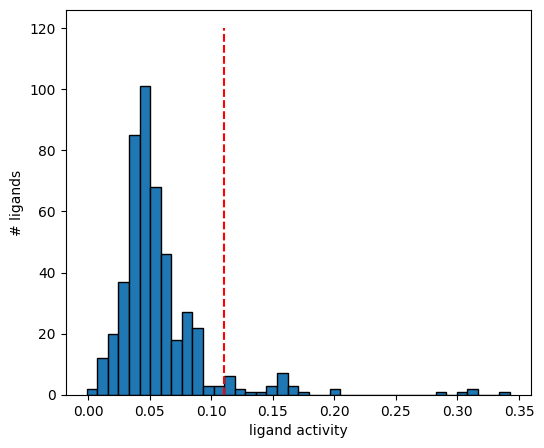

In [11]:
create_ligand_activity_hist(
    ligand_activities_sorted,
    figsize=(6, 5)
)

We can also visualize the ligand activity measure (AUPR) of these top-ranked ligands:

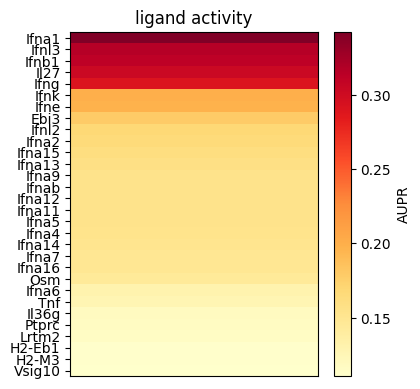

In [12]:
create_ligand_activity_heatmap(
    ligand_activities_sorted[:30],
    figsize=(4, 4)
)

NicheNet also infers active target genes of these top-ranked ligands, best visualized with the following heatmap showing which top-ranked ligands are predicted to have regulated the expression of which differentially expressed genes:

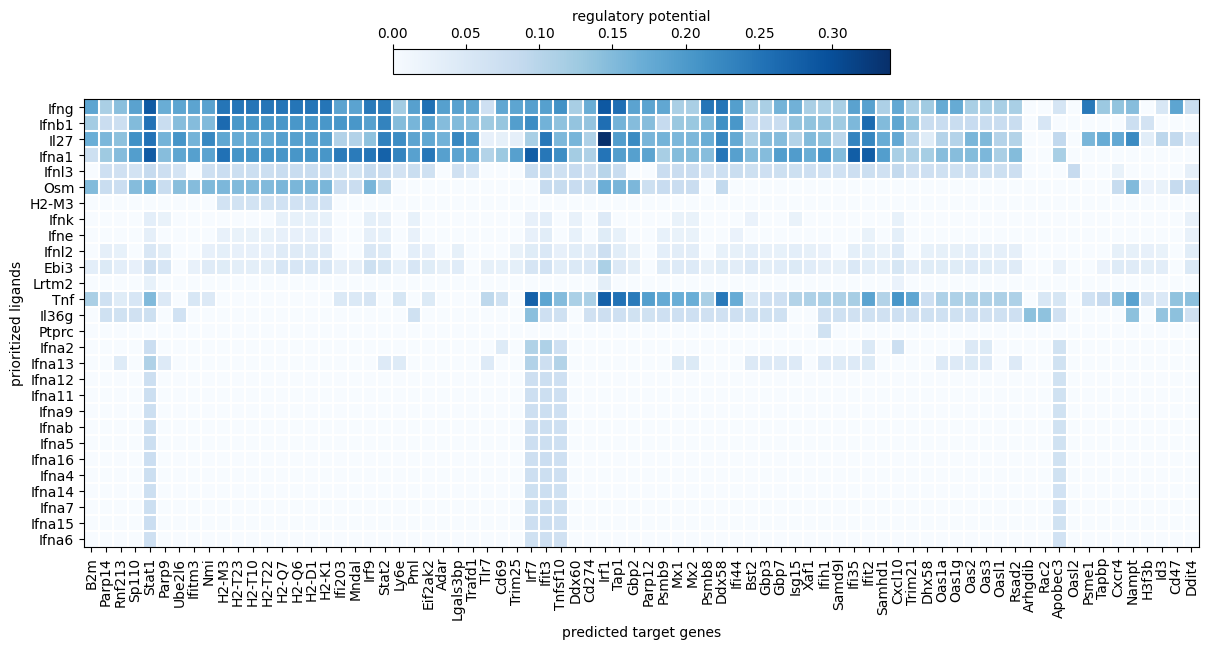

In [13]:
create_regulatory_potential_heatmap(
    predictor,
    active_ligand_target_links,
    figsize=(12, 6)
)

NicheNet also infers the receiver cell receptors of these top-ranked ligands. You can run following command for a heatmap visualization of the ligand-receptor links:

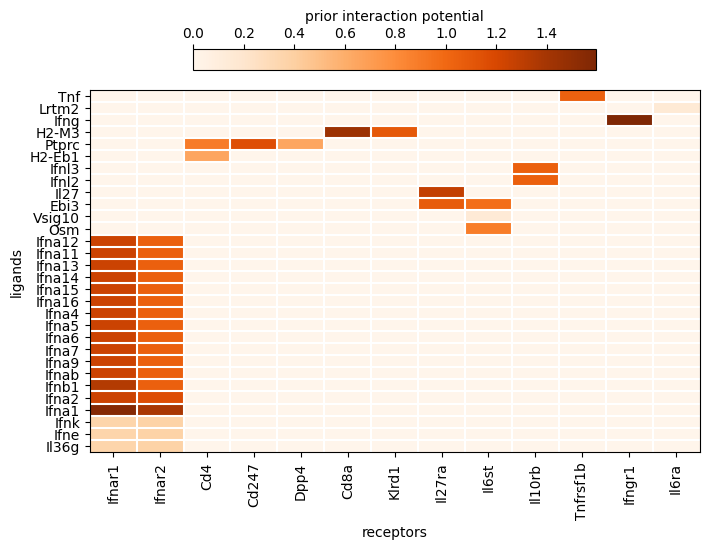

In [14]:
create_prior_interaction_potential_heatmap(
    ligand_receptor_links,
    figsize=(7, 5)
)

#### Sender-focused approach

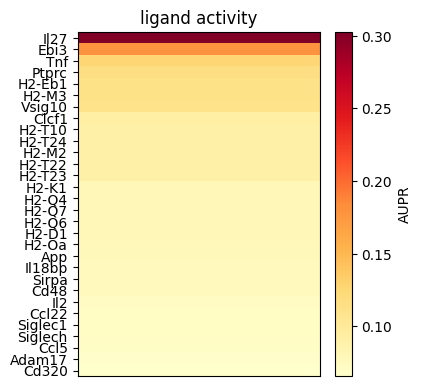

In [15]:
create_ligand_activity_heatmap(
    ligand_activities_sorted_focused[:30],
    figsize=(4, 4)
)

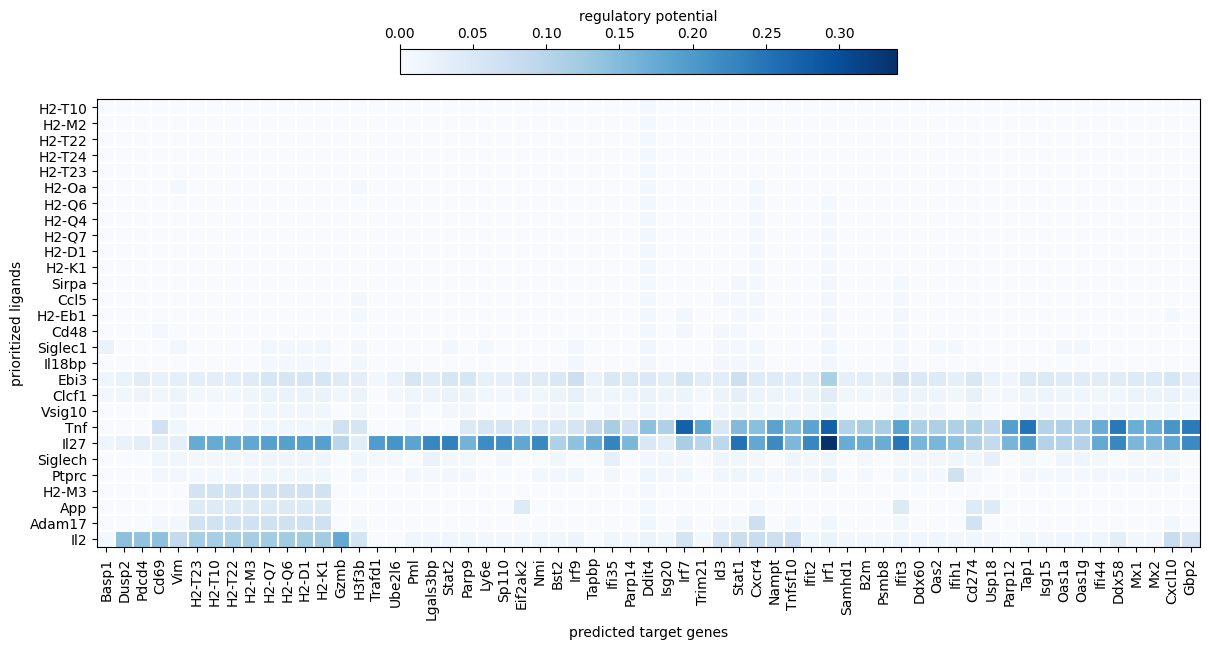

In [16]:
create_regulatory_potential_heatmap(
    predictor,
    active_ligand_target_links_focused,
    figsize=(12, 6)
)

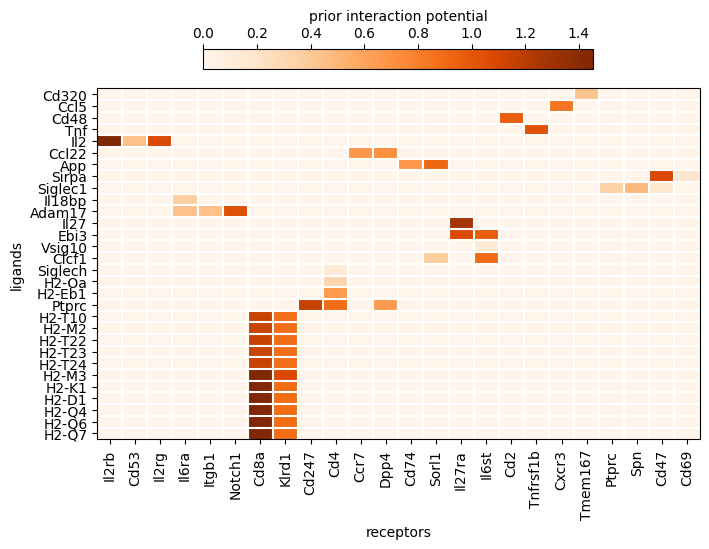

In [17]:
create_prior_interaction_potential_heatmap(
    ligand_receptor_links_focused,
    figsize=(7, 5)
)

#### Visualizing expression and log-fold change in sender cells

For the sender-focused approach, we can also investigate further on which sender cell populations are potentially the true sender of these ligands. First, we can simply check which sender cell population expresses which of these top-ranked ligands.

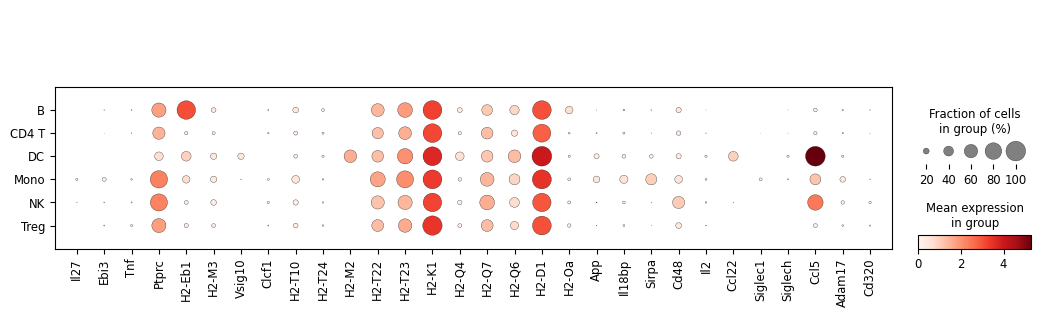

In [18]:
sc.pl.dotplot(
    ann_focused,
    var_names=best_upstream_ligands_focused,
    groupby="celltype",
    gene_symbols="gene"
)

As you can see, most of the top-ranked ligands seem to be mainly expressed by dendritic cells and monocytes.

Next, we can also check upregulation of ligands in sender cells by computing the log-fold change between the two conditions. This ligand differential expression is not used for prioritization and ranking of the ligands (the ranking is only determined based on enrichment of target genes among DE genes in the receiver, CD8T cells), but it can add a useful extra layer of information next to the ligand activities. This is of course only possible in some cases, such as case-control studies.

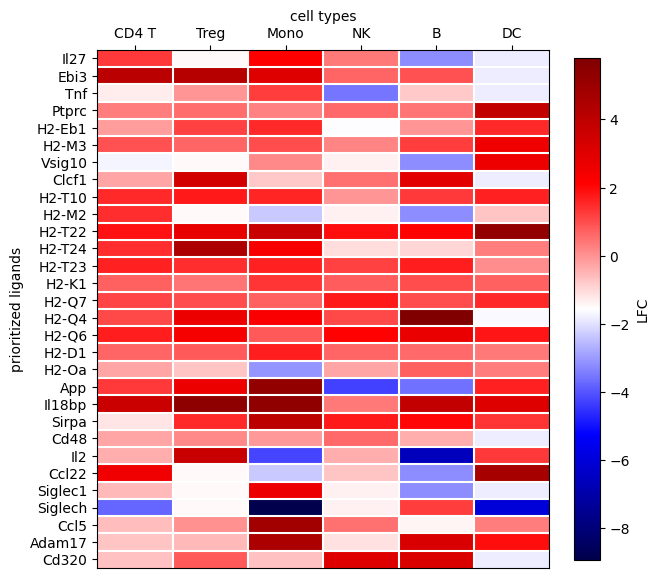

In [19]:
create_lfc_heatmap(
    sender_celltypes,
    dict(ligand_activities_sorted_focused),
    lfcs,
    figsize=(6, 6)
)

We see that most of the top-ranked ligands also seem to be upregulated themselves in monocytes after viral infection. This is nice additional “evidence” that these ligands might indeed be important.



Finally, you can also compare rankings between the sender-agnostic and sender-focused approach. Here, the red sections of the left bar plot indicates which ligands in the sender-agnostic approach are filtered out in the sender-focused approach because they are not expressed.

In [20]:
# TODO: custom graph